### 4.13 다변량 선형 회귀 분석 - 데이터 확보하기

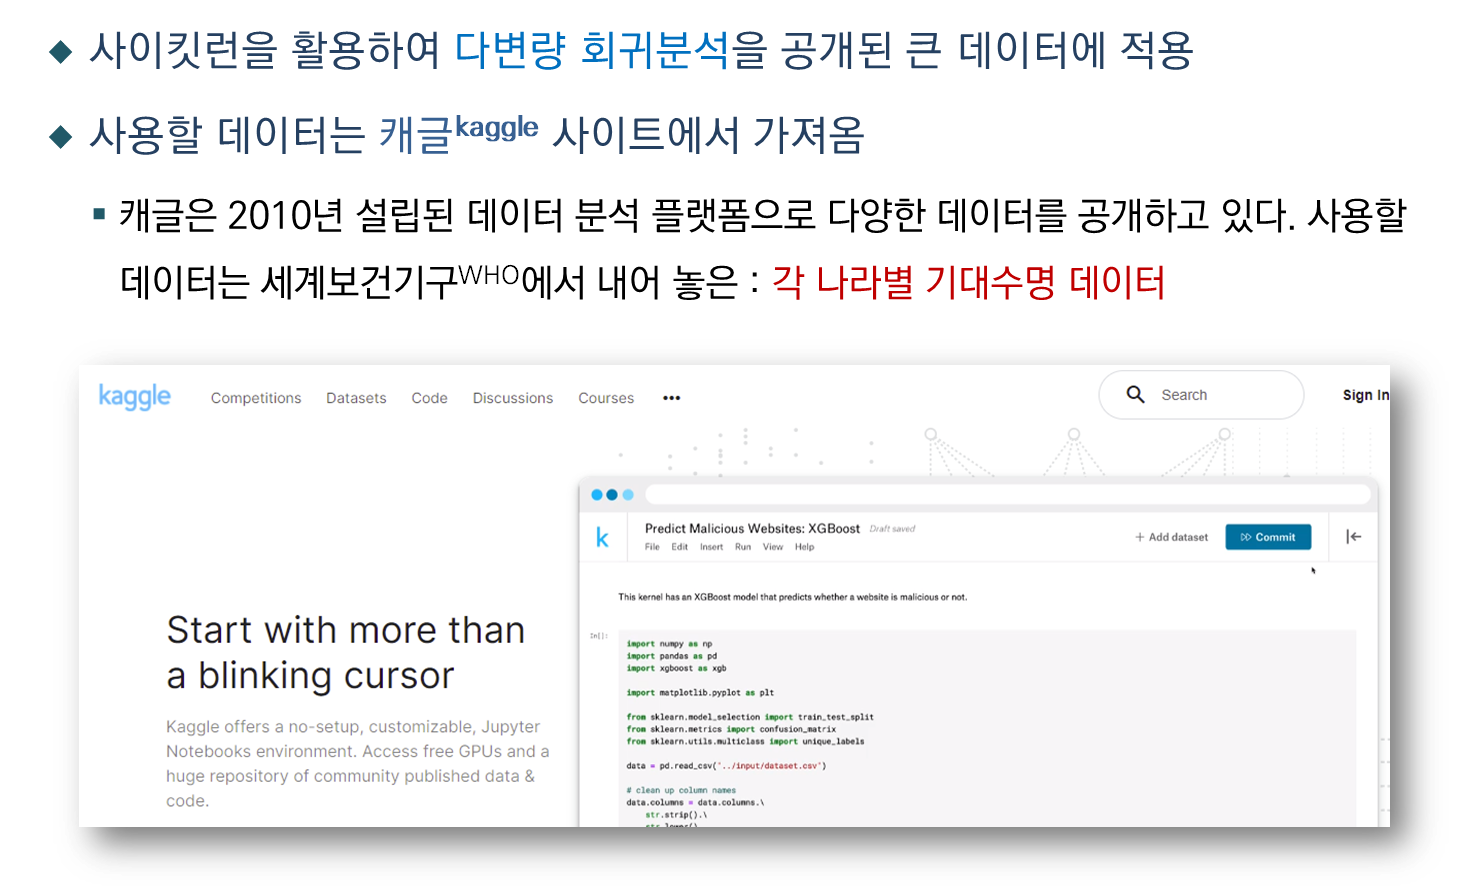

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns    # 시각화를 위하여 Seaborn 라이브러리를 이용함

life = pd.read_csv('./data/life_expectancy.csv')
life

,Country,Year,Status,Life expectancy,Adult mortality,Infant deaths,Alcohol,Percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 years,Thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [18]:
life.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult mortality',
       'Infant deaths', 'Alcohol', 'Percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'Under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', 'HIV/AIDS', 'GDP', 'Population', 'Thinness 1-19 years',
       'Thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [19]:
## 특정 열만 선택하여 새로운 데이터프레임 생성 (22 -> 12 컬럼만 생성)
life = life[['Life expectancy', 'Year', 'Alcohol',
           'Percentage expenditure', 'Total expenditure',
           'Hepatitis B', 'Measles', 'Polio', 'BMI', 'GDP',
           'Thinness 1-19 years', 'Thinness 5-9 years']]
life

,Life expectancy,Year,Alcohol,Percentage expenditure,Total expenditure,Hepatitis B,Measles,Polio,BMI,GDP,Thinness 1-19 years,Thinness 5-9 years
0,65.0,2015,0.01,71.279624,8.16,65.0,1154,6.0,19.1,584.259210,17.2,17.3
1,59.9,2014,0.01,73.523582,8.18,62.0,492,58.0,18.6,612.696514,17.5,17.5
2,59.9,2013,0.01,73.219243,8.13,64.0,430,62.0,18.1,631.744976,17.7,17.7
3,59.5,2012,0.01,78.184215,8.52,67.0,2787,67.0,17.6,669.959000,17.9,18.0
4,59.2,2011,0.01,7.097109,7.87,68.0,3013,68.0,17.2,63.537231,18.2,18.2
...,...,...,...,...,...,...,...,...,...,...,...,...
2933,44.3,2004,4.36,0.000000,7.13,68.0,31,67.0,27.1,454.366654,9.4,9.4
2934,44.5,2003,4.06,0.000000,6.52,7.0,998,7.0,26.7,453.351155,9.8,9.9
2935,44.8,2002,4.43,0.000000,6.53,73.0,304,73.0,26.3,57.348340,1.2,1.3
2936,45.3,2001,1.72,0.000000,6.16,76.0,529,76.0,25.9,548.587312,1.6,1.7


크기는 shape 속성으로 알 수 있고, 결손값은 isnull() 함수를 이용
결손값이 있는 데이터는 모두 삭제  

In [20]:
life.isnull()

,Life expectancy,Year,Alcohol,Percentage expenditure,Total expenditure,Hepatitis B,Measles,Polio,BMI,GDP,Thinness 1-19 years,Thinness 5-9 years
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2933,False,False,False,False,False,False,False,False,False,False,False,False
2934,False,False,False,False,False,False,False,False,False,False,False,False
2935,False,False,False,False,False,False,False,False,False,False,False,False
2936,False,False,False,False,False,False,False,False,False,False,False,False


In [21]:
print(life.shape)
print(life.isnull().sum(axis=0))

(2938, 12)
Life expectancy            10
Year                        0
Alcohol                   194
Percentage expenditure      0
Total expenditure         226
Hepatitis B               553
Measles                     0
Polio                      19
BMI                        34
GDP                       448
Thinness 1-19 years        34
Thinness 5-9 years         34
dtype: int64


### 4.14 다변량 선형 회귀 분석 - 예측에 필요한 데이터를 추려 보자

In [23]:
life.dropna(inplace = True)
print(life.shape)

(1853, 12)


C:\Users\human\AppData\Local\Temp\ipykernel_12688\2881077672.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  life.dropna(inplace = True)


In [24]:
## 결측치 제거 완료 확인
life.isnull().sum(axis=0)

Life expectancy           0
Year                      0
Alcohol                   0
Percentage expenditure    0
Total expenditure         0
Hepatitis B               0
Measles                   0
Polio                     0
BMI                       0
GDP                       0
Thinness 1-19 years       0
Thinness 5-9 years        0
dtype: int64

In [7]:
# sns.set(rc={'figure.figsize':(12,10)})    # 상관행렬 가시
sns.set_theme(rc={'figure.figsize':(12,10)})    # 상관행렬 가시

## 상관행렬을 그리기 위해 숫자형 데이터만 추출
numeric_life = life.select_dtypes(include=[float, int])
numeric_life.shape

(1853, 12)

In [25]:
correlation_matrix = numeric_life.corr().round(2) # 상관행렬 생성

correlation_matrix

,Life expectancy,Year,Alcohol,Percentage expenditure,Total expenditure,Hepatitis B,Measles,Polio,BMI,GDP,Thinness 1-19 years,Thinness 5-9 years
Life expectancy,1.00,0.04,0.35,0.41,0.12,0.22,-0.08,0.35,0.52,0.44,-0.45,-0.46
Year,0.04,1.00,-0.09,0.08,0.08,0.10,-0.05,-0.02,0.00,0.10,0.02,0.01
Alcohol,0.35,-0.09,1.00,0.36,0.27,0.06,-0.04,0.19,0.30,0.30,-0.40,-0.38
Percentage expenditure,0.41,0.08,0.36,1.00,0.14,0.02,-0.07,0.14,0.24,0.91,-0.25,-0.26
Total expenditure,0.12,0.08,0.27,0.14,1.00,0.05,-0.09,0.06,0.14,0.05,-0.21,-0.21
Hepatitis B,0.22,0.10,0.06,0.02,0.05,1.00,-0.13,0.47,0.15,0.08,-0.12,-0.13
Measles,-0.08,-0.05,-0.04,-0.07,-0.09,-0.13,1.00,-0.07,-0.15,-0.07,0.18,0.18
Polio,0.35,-0.02,0.19,0.14,0.06,0.47,-0.07,1.00,0.20,0.18,-0.16,-0.17
BMI,0.52,0.00,0.30,0.24,0.14,0.15,-0.15,0.20,1.00,0.26,-0.51,-0.52
GDP,0.44,0.10,0.30,0.91,0.05,0.08,-0.07,0.18,0.26,1.00,-0.25,-0.25


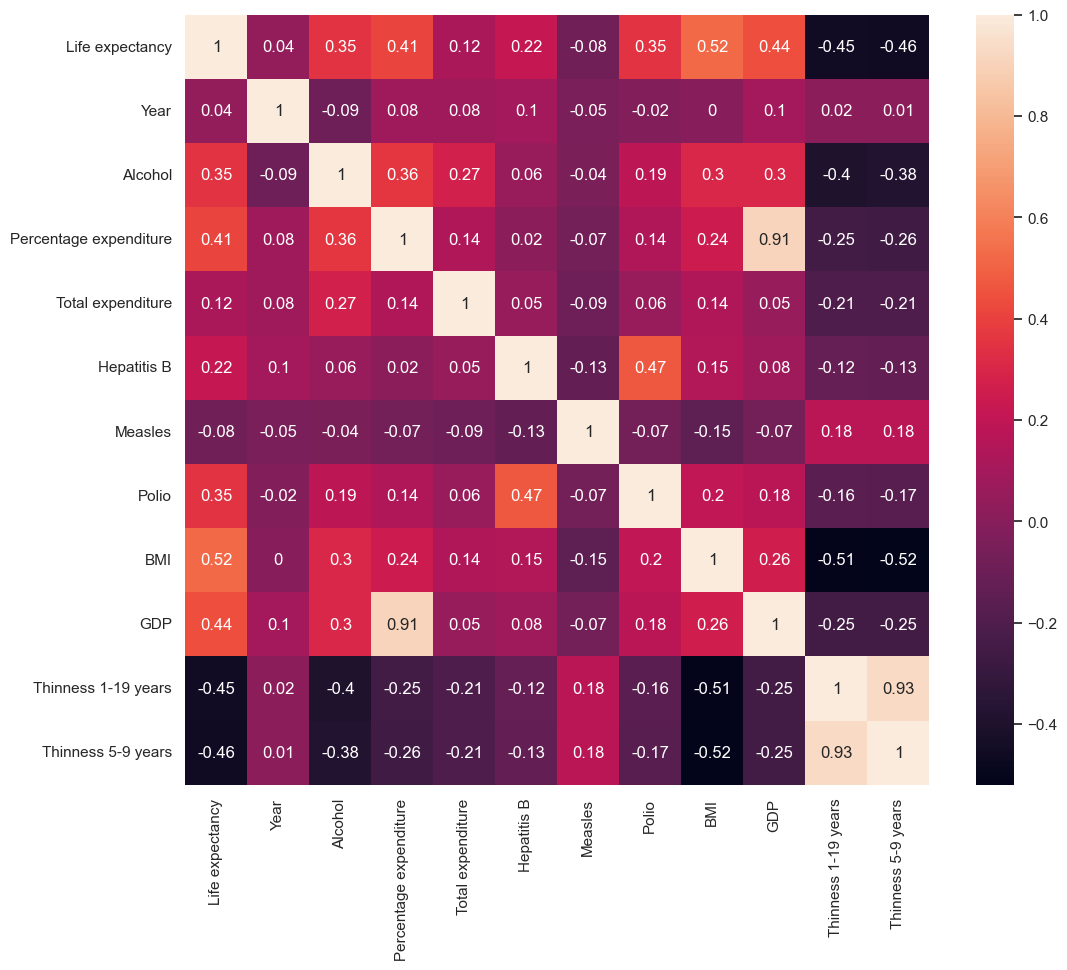

In [26]:

sns.heatmap(data=correlation_matrix, annot=True)
plt.show()  # colab 등 노트북 환경에서는 필요없지만, 콘솔 환경 등에서는 필요

### 4.15 다변량 선형 회귀 분석 - 쌍 그림으로 확인하고 중요 특징만 추출

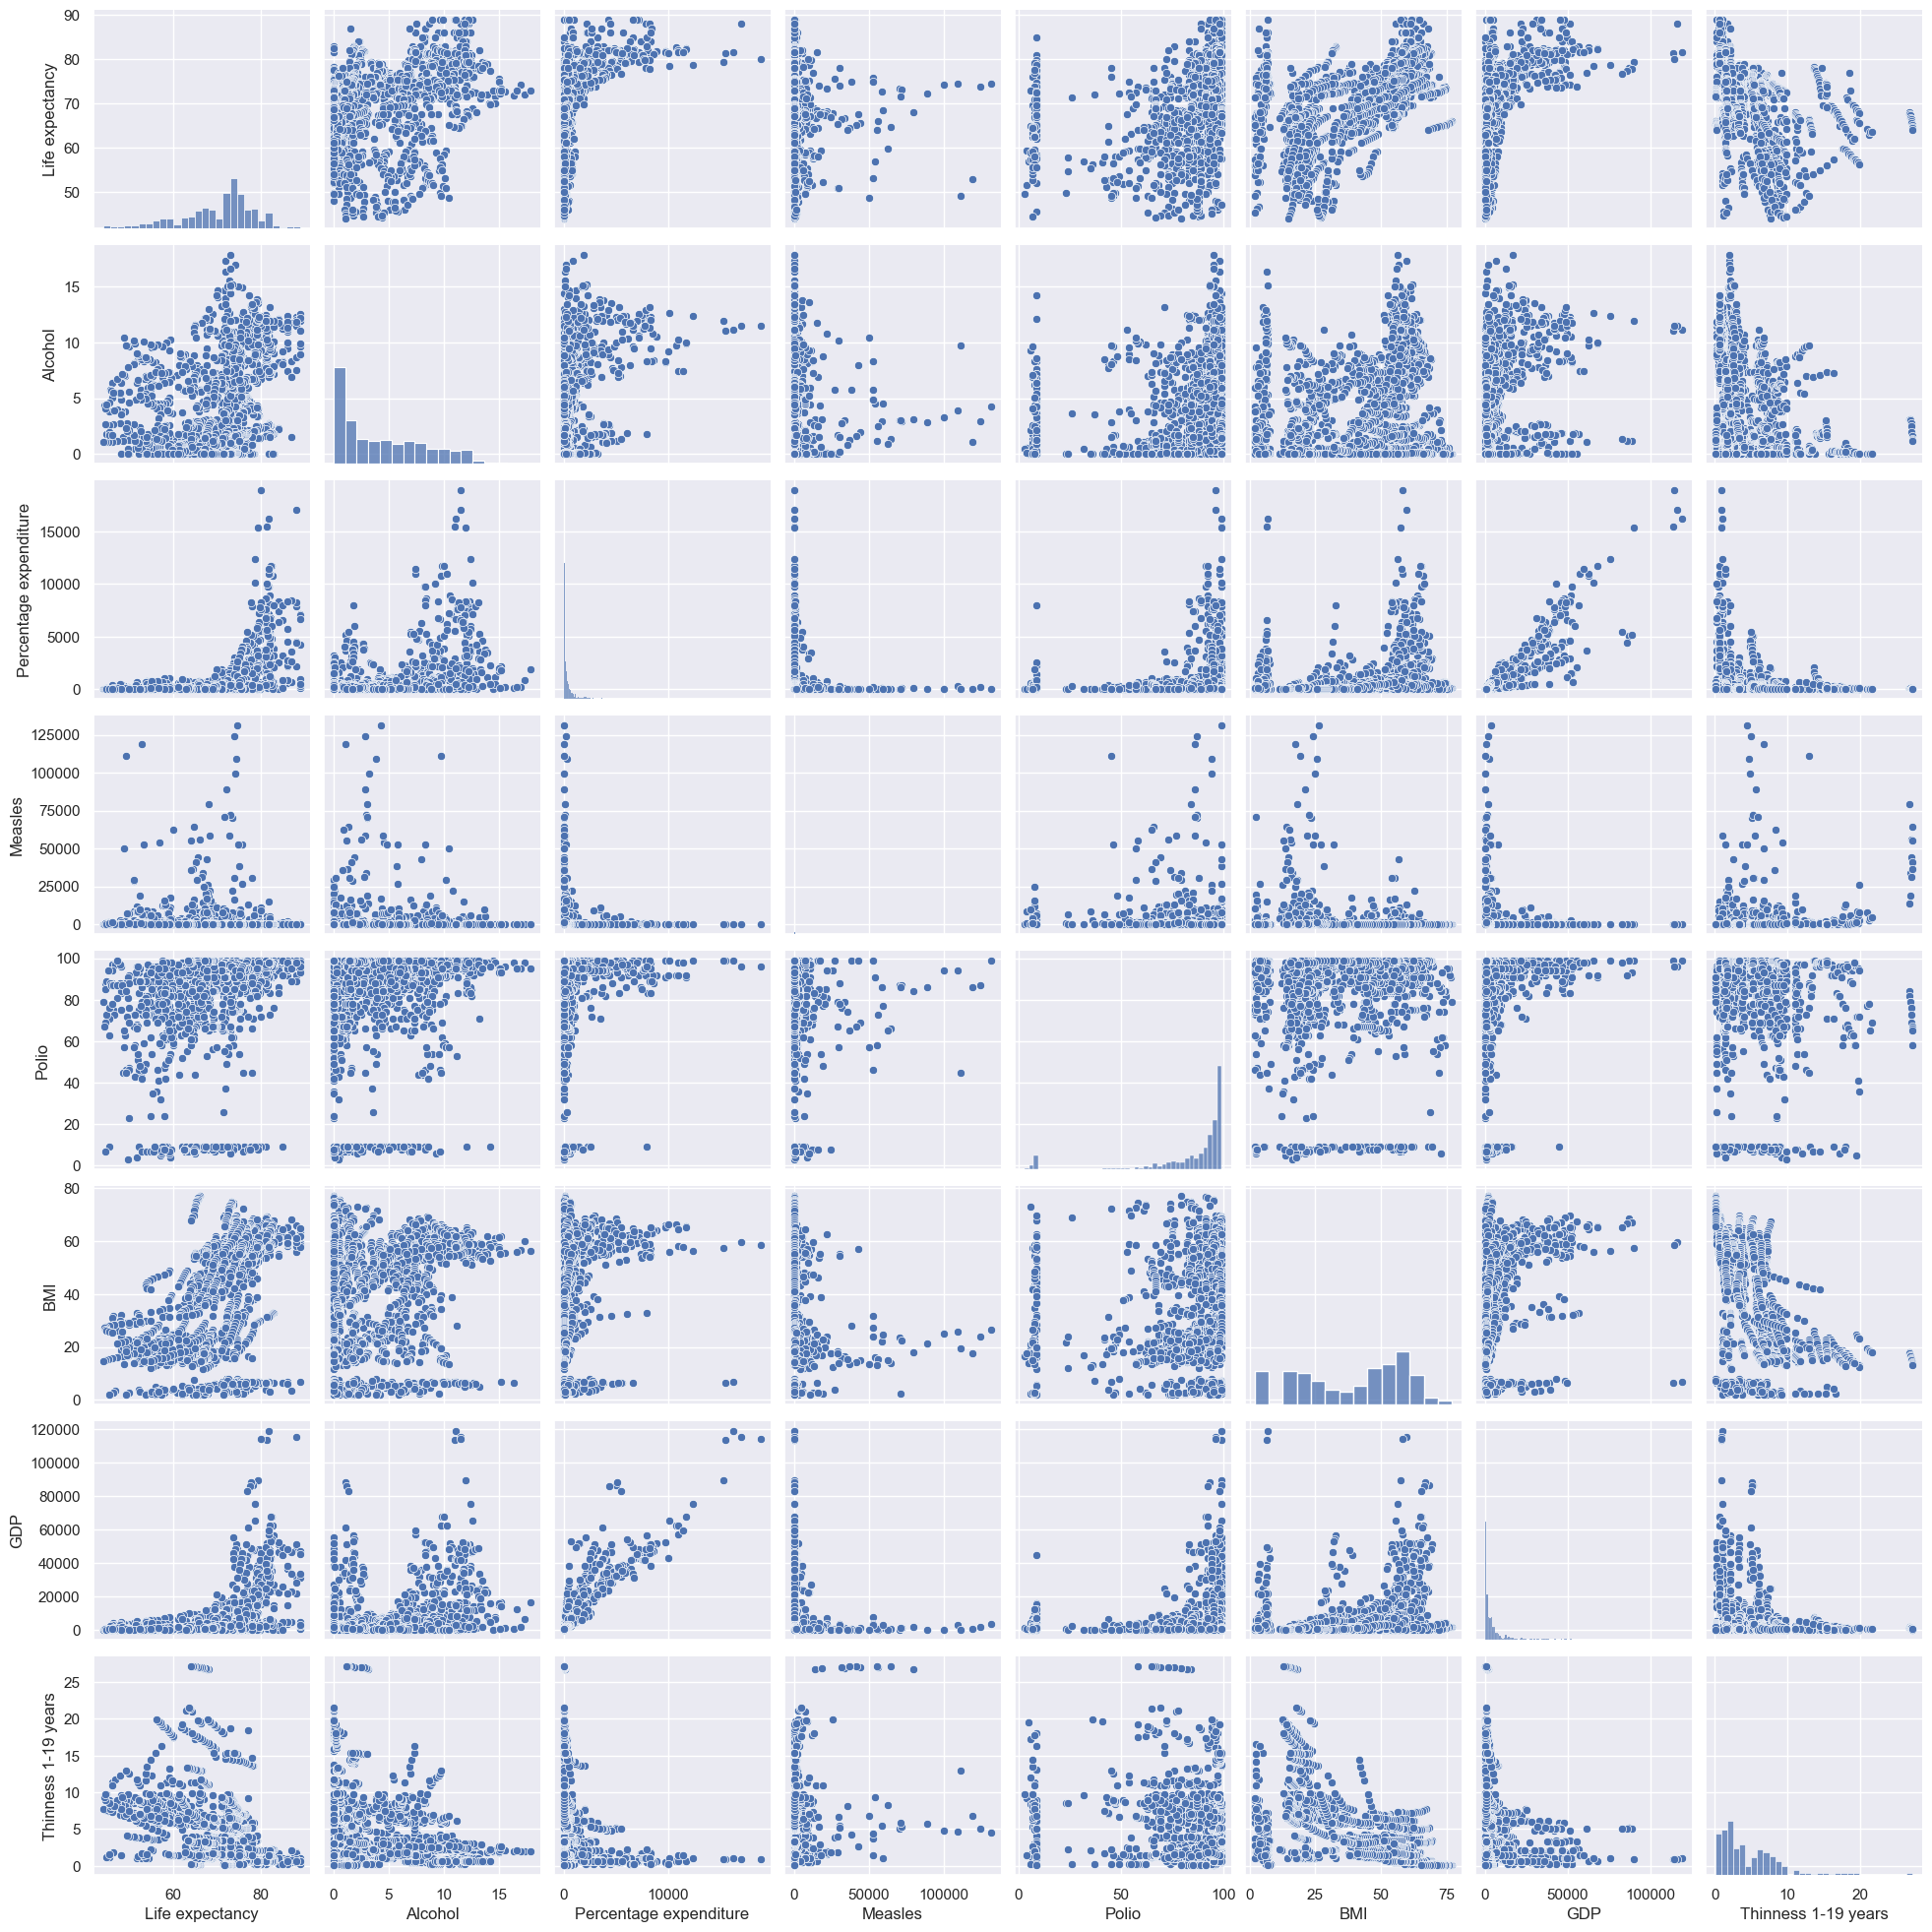

In [27]:
sns.pairplot(life[['Life expectancy', 'Alcohol', 'Percentage expenditure', 'Measles', 'Polio', 'BMI', 'GDP', 'Thinness 1-19 years']])
plt.show()  # colab 등 노트북 환경에서는 필요없지만, 콘솔 환경 등에서는 필요

In [28]:
X = life[['Alcohol', 'Percentage expenditure', 'Polio',
         'BMI', 'GDP', 'Thinness 1-19 years']]
y = life['Life expectancy']
# print(X)
print(y)
X

0       65.0
1       59.9
2       59.9
3       59.5
4       59.2
        ... 
2933    44.3
2934    44.5
2935    44.8
2936    45.3
2937    46.0
Name: Life expectancy, Length: 1853, dtype: float64


,Alcohol,Percentage expenditure,Polio,BMI,GDP,Thinness 1-19 years
0,0.01,71.279624,6.0,19.1,584.259210,17.2
1,0.01,73.523582,58.0,18.6,612.696514,17.5
2,0.01,73.219243,62.0,18.1,631.744976,17.7
3,0.01,78.184215,67.0,17.6,669.959000,17.9
4,0.01,7.097109,68.0,17.2,63.537231,18.2
...,...,...,...,...,...,...
2933,4.36,0.000000,67.0,27.1,454.366654,9.4
2934,4.06,0.000000,7.0,26.7,453.351155,9.8
2935,4.43,0.000000,73.0,26.3,57.348340,1.2
2936,1.72,0.000000,76.0,25.9,548.587312,1.6


### 4.16 다변량 선형 회귀 분석 - 데이터를 훈련용과 검증용으로 분리해 학습

In [29]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns    # 시각화를 위하여 Seaborn 라이브러리를 이용함

data_loc = 'https://github.com/dknife/ML/raw/main/data/'
life = pd.read_csv(data_loc + 'life_expectancy.csv')
life.dropna(inplace = True)

X = life[['Alcohol', 'Percentage expenditure', 'Polio',
         'BMI', 'GDP', 'Thinness 1-19 years']]
y = life['Life expectancy']
X.shape, y.shape

((1649, 6), (1649,))

In [30]:
X

,Alcohol,Percentage expenditure,Polio,BMI,GDP,Thinness 1-19 years
0,0.01,71.279624,6.0,19.1,584.259210,17.2
1,0.01,73.523582,58.0,18.6,612.696514,17.5
2,0.01,73.219243,62.0,18.1,631.744976,17.7
3,0.01,78.184215,67.0,17.6,669.959000,17.9
4,0.01,7.097109,68.0,17.2,63.537231,18.2
...,...,...,...,...,...,...
2933,4.36,0.000000,67.0,27.1,454.366654,9.4
2934,4.06,0.000000,7.0,26.7,453.351155,9.8
2935,4.43,0.000000,73.0,26.3,57.348340,1.2
2936,1.72,0.000000,76.0,25.9,548.587312,1.6


In [31]:
y

0       65.0
1       59.9
2       59.9
3       59.5
4       59.2
        ... 
2933    44.3
2934    44.5
2935    44.8
2936    45.3
2937    46.0
Name: Life expectancy, Length: 1649, dtype: float64

In [41]:
## 학습 데이터와 테스트 데이터를 8:2로 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1319, 6), (330, 6), (1319,), (330,))

In [42]:
1649 * 0.8, 1649 * 0.2

(1319.2, 329.8)

In [47]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)   # 학습데이터로 학습 (1319개 샘플)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
lin_model.coef_  # 회귀계수 (기울기) : W 값들

array([ 1.68899804e-01, -3.28173510e-04,  7.70378312e-02,  1.43175404e-01,
        2.32306283e-04, -3.01665857e-01])

In [49]:
lin_model.intercept_  # 절편 : b 값

57.07209142786681

In [53]:
# 학습된 모델로 예측 수행
y_hat_test = lin_model.predict(X_test)
y_hat_test.shape

(330,)

In [54]:
y_hat_test

array([63.30051489, 59.26886365, 79.52948182, 66.56076395, 70.87043625,
       59.56395827, 59.61213618, 75.43847881, 67.75269679, 58.18578379,
       73.40209377, 69.12346113, 62.51928691, 68.9660584 , 71.57567857,
       83.51722088, 71.08078703, 73.14828975, 64.93425744, 83.78777474,
       66.10293824, 55.453322  , 67.4382159 , 70.12112651, 72.71831741,
       72.3668663 , 60.75172913, 67.35212341, 68.65186397, 74.18799481,
       64.57726519, 77.65278734, 62.02140817, 86.85642622, 63.90045116,
       71.37147036, 71.60313426, 77.10944237, 73.96844127, 59.60613412,
       63.77792251, 57.20475713, 64.72719002, 77.39273341, 74.45168383,
       61.77740686, 75.33945958, 68.85173274, 67.59697319, 64.20180994,
       71.40243515, 66.16390656, 71.21560755, 68.72857701, 65.03709149,
       64.91324616, 66.59118306, 64.62709415, 67.97940581, 71.8647746 ,
       67.00208851, 64.92857057, 72.45630012, 64.72003459, 75.0784472 ,
       74.04535504, 66.34885997, 75.60373845, 71.66678054, 65.26

In [55]:
import numpy as np
## y_hat_test (예측값)과 y_test 간의 mse 계산
np.mean((y_hat_test - y_test)**2)   # MSE

40.03368176961841

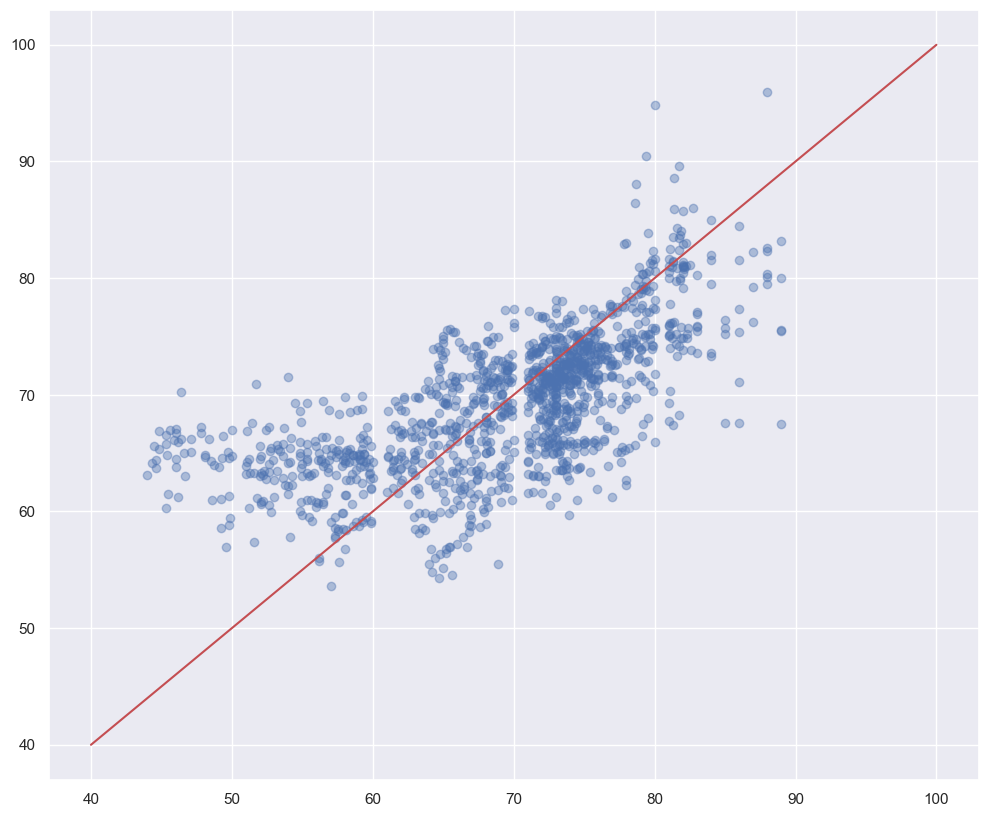

In [ ]:
y_hat_train = lin_model.predict(X_train)
y_hat_train.shape
plt.scatter(y_train, y_hat_train, alpha=0.4)  # 검증 데이터와 예측 데이터의 산포도 (실제 y, 예측 y)
xy_range = [40, 100]
plt.plot(xy_range, xy_range, "r")     # (40,40)에서 (10,100)으로 직선
                                 #   - 데이터가 이 직선과 일치할수록 예측이 정확
plt.show()
                                 

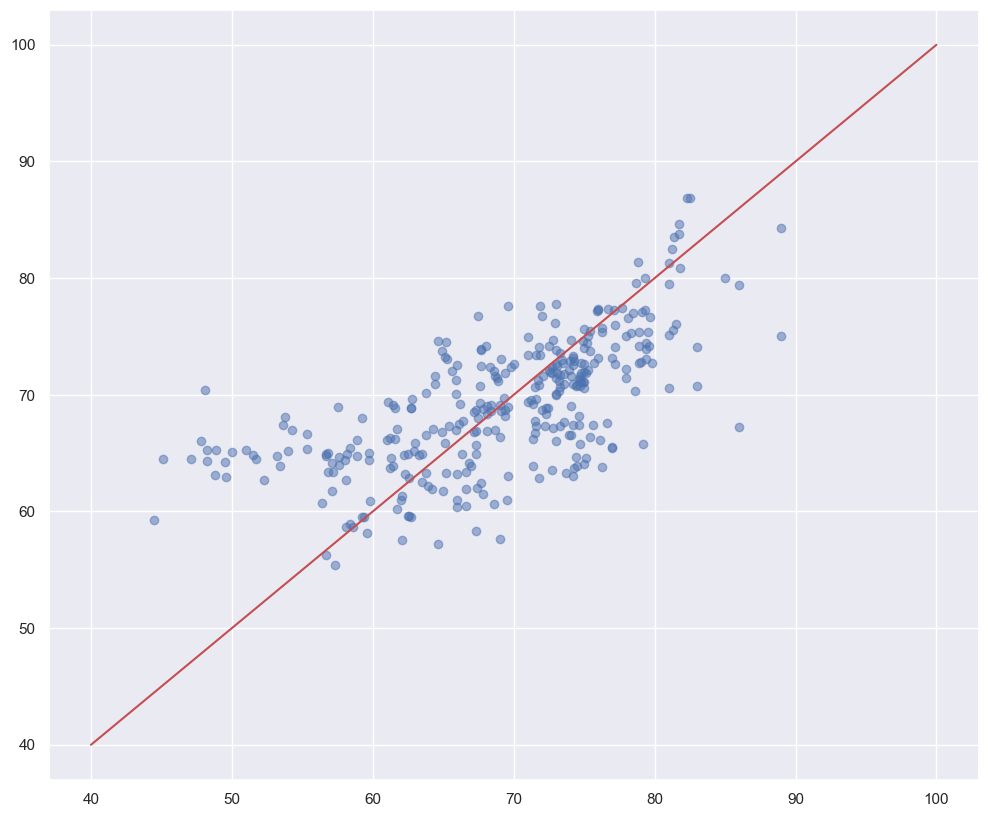

In [57]:
y_hat_test = lin_model.predict(X_test)
plt.scatter(y_test, y_hat_test, alpha=0.5)
plt.plot(xy_range, xy_range, "r")
plt.show()

In [58]:
from sklearn.metrics import mean_squared_error
print('Mean squared error:', mean_squared_error(y_test, y_hat_test))

Mean squared error: 40.03368176961841


In [59]:
## R² 값 확인
lin_model.score(X_train, y_train), lin_model.score(X_test, y_test)

(0.4502835719104231, 0.43753617665020084)

In [60]:
## mean squared error 계산 (위의 함수의 결과와 일치)
((y_test - y_hat_test)**2).mean()

40.03368176961841

##  5-1 텐서플로에서 실행하는 단순 선형회귀

In [ ]:
#######################################################
# [tf + keras] 단순선형회귀 : 공부시간 예제
#######################################################
import numpy as np
import matplotlib.pyplot as plt

#텐서플로의 케라스 API에서 필요한 함수들을 불러 옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

X = np.array([2, 4, 6, 8])
y = np.array([81, 93, 91, 97]) 

model = Sequential()

# 출력 값, 입력 변수, 분석 방법에 맞게끔 모델을 설정합니다. 
model.add(Dense(1, input_dim=1, activation='linear'))

# 오차 수정을 위해 경사 하강법(sgd)을, 오차의 정도를 판단하기 위해 평균 제곱 오차(mse)를 사용합니다. 
# model.compile(optimizer='sgd', loss='mse')
model.compile(optimizer=SGD(learning_rate=0.01), loss='mse')

# 오차를 최소화하는 과정을 2000번 반복합니다.
history = model.fit(X, y, epochs=2000)

plt.scatter(X, y)
plt.plot(X, model.predict(X),'r')    # 예측 결과를 그래프로 나타냅니다.
plt.show()

In [ ]:
#임의의 시간을 집어넣어 점수를 예측하는 모델을 테스트해 보겠습니다.
hour = 7.0  # float로 넣어 주어야 함 (최근 버전)
prediction = model.predict(np.array([[hour]]))  # 반드시 2차원 array로 넣어 주어야 함

print("%.f시간을 공부할 경우의 예상 점수는 %.02f점입니다" % (hour, prediction[0][0]))

In [ ]:
hour, prediction

In [ ]:
model.get_weights()

In [ ]:
history.history

## 5-2 텐서플로에서 실행하는 다중 선형회귀 모델

In [ ]:
#######################################################
# [tf + keras] 다중선형회귀 : 공부시간&과외시간 예제
#######################################################
import numpy as np
import matplotlib.pyplot as plt

#텐서플로의 케라스 API에서 필요한 함수들을 불러 옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 데이터 준비
X = np.array([[2, 0], [4, 4], [6, 2], [8, 3]])
y = np.array([81, 93, 91, 97]) 

# 모델 만들기
model = Sequential()

#입력 변수가 2개(학습 시간, 과외 시간)이므로 input_dim에 2를 입력합니다. 
model.add(Dense(1, input_dim=2, activation='linear'))
model.compile(optimizer='sgd' ,loss='mse')

# 모델 실행 (train 수행)
hist = model.fit(X, y, epochs=2000)

In [ ]:
#임의의 학습 시간과 과외 시간을 집어넣어 점수를 예측하는 모델을 테스트해 보겠습니다.
hour = 7
private_class = 4
prediction = model.predict(np.array([[hour, private_class]]))  # 반드시 2차원 array로 넣어 주어야 함

print("%.f시간을 공부하고 %.f시간의 과외를 받을 경우, 예상 점수는 %.02f점입니다" % (hour, private_class, prediction))

In [ ]:
hist.history['loss']

In [ ]:
plt.plot(hist.history['loss'])

In [ ]:
model.get_weights()

In [ ]:
#################################################################
#  로지스틱 회귀 (Sigmoid) : numpy로 학습
#  - 공부시간과 학습 예제
#################################################################
import numpy as np
import matplotlib.pyplot as plt

#공부시간 X와 성적 Y의 리스트를 만듭니다.
data = np.array([[2, 0], [4, 0], [6, 0], [8, 1], [10, 1], [12, 1], [14, 1]])
X = data[:, 0]  # shape: (7, )
Y = data[:, 1]  # shape: (7, )

# 임의의 초기값 설정
a, b = 100, 10  # 기울기, 절편
lr = 0.1        # 학습률

#시그모이드 함수를 정의합니다.
def sigmoid(z):
    return 1 / (1 + np.exp(-z))  # shape: (7, )

# cost 함수 정의
def cost(a, b):  # 실수
    return - (Y * np.log(sigmoid(a * X + b)) +(1 - Y) * np.log(1 - sigmoid(X))).mean()

#경사 하강법을 실행합니다.
for i in range(1001):
    error = sigmoid(a * X + b) - Y  # 편차 : shape: (7, )
    a_diff = 2 * (error * X).mean()   # 실수
    b_diff = 2 * error.mean()         # 실수  
    
    a = a - lr * a_diff     # 실수
    b = b - lr * b_diff     # 실수
    if i % 100 == 0:    # 1000번 반복될 때마다 각 x_data값에 대한 현재의 a값, b값을 출력합니다.
        print("epoch=%.f, 기울기=%.04f, 절편=%.04f  Cost=%.4f" % (i, a, b, cost(a, b)))
    
# 앞서 구한 기울기와 절편을 이용해 그래프를 그려 봅니다.
plt.scatter(X, Y)   # X: (7, ), Y:(7, )
plt.xlim(0, 15)
plt.ylim(-.1, 1.1)
x_range = (np.arange(0, 15, 0.1)) #그래프로 나타낼 x값의 범위 설정
plt.plot(x_range, sigmoid(a * x_range + b),"r")
plt.show()


In [ ]:
#################################################################
#  로지스틱 회귀 (Sigmoid) : numpy로 학습
#  - 공부시간과 학습 예제
#################################################################
import numpy as np
import matplotlib.pyplot as plt

#공부시간 X와 성적 Y의 리스트를 만듭니다.
data = np.array([[2, 0], [4, 0], [6, 0], [8, 1], [10, 1], [12, 1], [14, 1]])
X = data[:, 0]
Y = data[:, 1]

# weight와 bias의 초기값 설정
w, b = 1, 2     # 기울기, 절편
lr = 0.1       # 학습률
epoch = 5001    # 학습횟수

# 시그모이드 함수 정의
def sigmoid(w, b, X):
    return 1 / (1 + np.exp(-(w*X + b)))

# cost함수 정의  : Binary Cross Entropy
def cost(h):
    return (- (Y * np.log(h) + (1 - Y) * np.log(1 - h))).mean()

# 경사 하강법 실시
for i in range(epoch):
    error = sigmoid(w, b, X) - Y  # 각 x에서의 오차(편차)
    w_diff = (error * X).mean()     # cost를 w로 미분
    b_diff = error.mean()           # cost를 b로 미분

    # w와 b 업데이트
    w = w - lr * w_diff
    b = b - lr * b_diff
    h = sigmoid(w, b, X)
    
    if i % 200 == 0:
        print("epoch=%.f, 기울기=%.04f, 절편=%.04f  Cost=%.4f" % (i, w, b, cost(h)))


In [ ]:
# 앞서 구한 기울기와 절편을 이용해 그래프를 그려 봅니다.
plt.scatter(X, Y)   # X: (7, ), Y:(7, )
plt.xlim(0, 15)
plt.ylim(-.1, 1.1)
x_range = (np.arange(0, 15, 0.1)) #그래프로 나타낼 x값의 범위 설정
plt.plot(x_range, sigmoid(w, b, x_range),"r")
plt.show()